In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mesa.batchrunner import batch_run
from model import InformationModel, INFO_LEVELS

### Batch 1 — Vary Cognitive Capacity
Signal noise and task complexity held at 0.0. Cognitive capacity varied from 2 to 14.

In [12]:
results1 = batch_run(
    InformationModel,
    parameters={
        'cognitive_capacity': list(range(2, 16, 2)),
        'signal_noise':       [0.0],
        'task_complexity':    [0.0],
    },
    rng=[None] * 5,
    max_steps=100,
    data_collection_period=1,
    display_progress=True,
)
df1 = pd.DataFrame(results1)
df1 = df1[df1['Step'] > 0]   # drop Step 0 initialisation rows
df1.to_csv('batch_capacity.csv', index=False)

  0%|          | 0/35 [00:00<?, ?it/s]

In [6]:
# Table 1 — mean quality per capacity × load combination
load_cols = [str(l) for l in INFO_LEVELS]
cap_means = df1.groupby('cognitive_capacity')[load_cols].mean()
print('Table 1 — Mean Decision Quality by Cognitive Capacity and Info Load')
cap_means.round(2)

Table 1 — Mean Decision Quality by Cognitive Capacity and Info Load


,1,3,5,8,12,18
cognitive_capacity,,,,,,
2,0.39,0.63,0.63,0.60,0.56,0.53
4,0.22,0.53,0.63,0.62,0.57,0.54
6,0.15,0.39,0.57,0.63,0.59,0.56
8,0.12,0.31,0.46,0.63,0.61,0.56
10,0.10,0.26,0.39,0.55,0.63,0.58
12,0.08,0.22,0.34,0.49,0.63,0.59
14,0.07,0.19,0.30,0.44,0.58,0.62


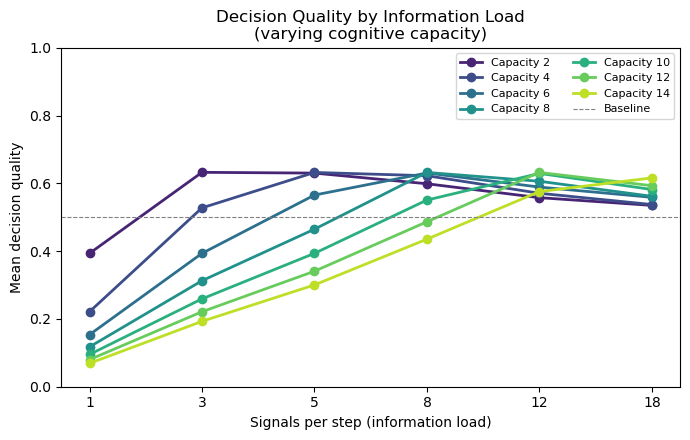

In [ ]:
# Figure 1 — Line chart: quality vs load
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = cm.viridis(np.linspace(0.1, 0.9, len(cap_means)))
for (cap, row), col in zip(cap_means.iterrows(), colors):
    ax.plot(load_cols, row.values,
            marker='o', label=f'Capacity {int(cap)}', color=col, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline')
ax.set_title('Decision Quality by Information Load\n(varying cognitive capacity)')
ax.set_xlabel('Signals per step (information load)')
ax.set_ylabel('Mean decision quality')
ax.set_ylim(0, 1)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

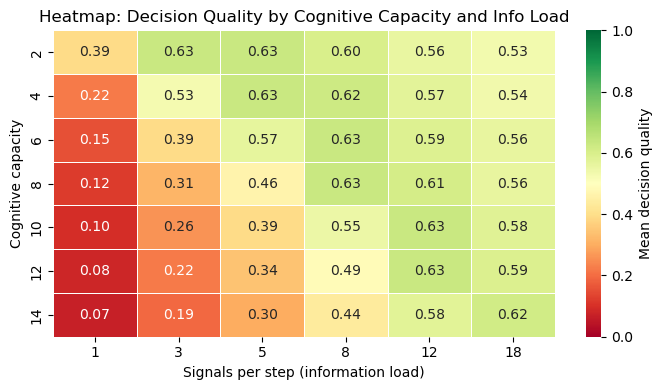

In [9]:
# Figure 2 — Heatmap: capacity x load
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    cap_means.astype(float),
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Mean decision quality'}
)
ax.set_title('Heatmap: Decision Quality by Cognitive Capacity and Info Load')
ax.set_xlabel('Signals per step (information load)')
ax.set_ylabel('Cognitive capacity')
plt.tight_layout()
plt.show()

### Batch 2 — Vary Signal Noise
Cognitive capacity fixed at 6. Task complexity held at 0.0. Signal noise varied at 0.0, 0.25, and 0.5.

In [11]:
results2 = batch_run(
    InformationModel,
    parameters={
        'cognitive_capacity': [6],
        'signal_noise':       [0.0, 0.25, 0.5],
        'task_complexity':    [0.0],
    },
    rng=[None] * 5,
    max_steps=100,
    data_collection_period=1,
    display_progress=True,
)
df2 = pd.DataFrame(results2)
df2 = df2[df2['Step'] > 0]
df2.to_csv('batch_noise.csv', index=False)

  0%|          | 0/15 [00:00<?, ?it/s]

In [13]:
# Table 2 — mean quality per noise level x load
noise_means = df2.groupby('signal_noise')[load_cols].mean()
print('Table 2 — Mean Decision Quality by Signal Noise and Info Load (capacity = 6)')
noise_means.round(2)

Table 2 — Mean Decision Quality by Signal Noise and Info Load (capacity = 6)


,1,3,5,8,12,18
signal_noise,,,,,,
0.00,0.15,0.39,0.57,0.64,0.59,0.56
0.25,0.15,0.39,0.56,0.61,0.58,0.55
0.50,0.16,0.40,0.55,0.59,0.58,0.55


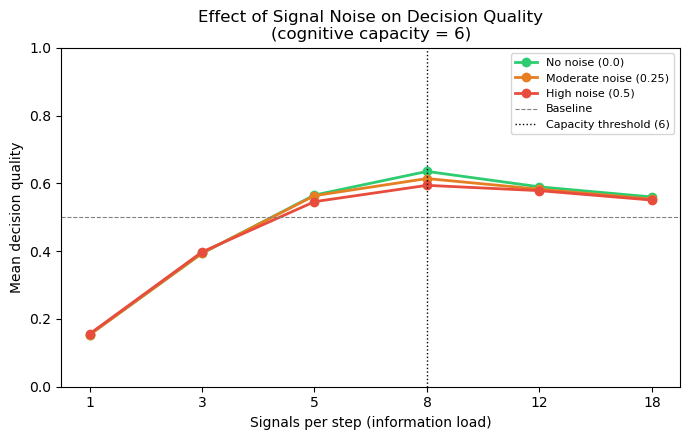

In [ ]:
# Figure 3 — Line chart: quality vs load
fig, ax = plt.subplots(figsize=(7, 4.5))
colors  = ['#2ecc71', '#e67e22', '#e74c3c']
labels  = ['No noise (0.0)', 'Moderate noise (0.25)', 'High noise (0.5)']
for (noise, row), col, lbl in zip(noise_means.iterrows(), colors, labels):
    ax.plot(load_cols, row.values,
            marker='o', label=lbl, color=col, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline')
ax.axvline(load_cols.index('8'), color='black', linestyle=':', linewidth=1, label='Capacity threshold (6)')
ax.set_title('Effect of Signal Noise on Decision Quality\n(cognitive capacity = 6)')
ax.set_xlabel('Signals per step (information load)')
ax.set_ylabel('Mean decision quality')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Batch 3 — Vary Task Complexity
Cognitive capacity fixed at 6. Signal noise held at 0.0. Task complexity varied at 0.0, 0.5, and 0.9.

In [15]:
results3 = batch_run(
    InformationModel,
    parameters={
        'cognitive_capacity': [6],
        'signal_noise':       [0.0],
        'task_complexity':    [0.0, 0.5, 0.9],
    },
    rng=[None] * 5,
    max_steps=100,
    data_collection_period=1,
    display_progress=True,
)
df3 = pd.DataFrame(results3)
df3 = df3[df3['Step'] > 0]
df3.to_csv('batch_complexity.csv', index=False)

  0%|          | 0/15 [00:00<?, ?it/s]

In [16]:
# Table 3 — mean quality per complexity level x load
complexity_means = df3.groupby('task_complexity')[load_cols].mean()
print('Table 3 — Mean Decision Quality by Task Complexity and Info Load (capacity = 6)')
complexity_means.round(2)

Table 3 — Mean Decision Quality by Task Complexity and Info Load (capacity = 6)


,1,3,5,8,12,18
task_complexity,,,,,,
0.0,0.15,0.39,0.57,0.63,0.60,0.55
0.5,0.15,0.28,0.28,0.49,0.63,0.62
0.9,0.15,0.15,0.15,0.15,0.15,0.28


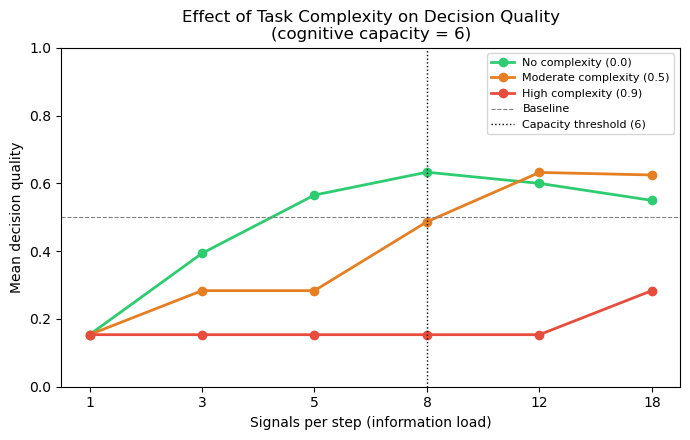

In [17]:
# Figure 4 — Line chart: quality vs load
fig, ax = plt.subplots(figsize=(7, 4.5))
colors  = ['#2ecc71', '#e67e22', '#e74c3c']
labels  = ['No complexity (0.0)', 'Moderate complexity (0.5)', 'High complexity (0.9)']
for (comp, row), col, lbl in zip(complexity_means.iterrows(), colors, labels):
    ax.plot(load_cols, row.values,
            marker='o', label=lbl, color=col, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline')
ax.axvline(load_cols.index('8'), color='black', linestyle=':', linewidth=1, label='Capacity threshold (6)')
ax.set_title('Effect of Task Complexity on Decision Quality\n(cognitive capacity = 6)')
ax.set_xlabel('Signals per step (information load)')
ax.set_ylabel('Mean decision quality')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()